# CSCAS baseline comparison

Compares twelve baseline families evaluated on the identical CSCAS train/test split and training-pool protocol (see `baselines/cscas.py`, `baselines/cscas_base.py`, `baselines/cscas_mining.py`, `baselines/cscas_logreg.py`, `baselines/cscas_xgboost.py`, `baselines/cscas_bert.py`, `baselines/cscas_securebert.py`, `baselines/cscas_zeroshot.py`, `baselines/cscas_anomaly.py`, `baselines/cscas_anomaly_iforest.py`, `baselines/cscas_mining_anomaly.py`, `baselines/cscas_mining_anomaly_iforest.py`):

1. **Paper** -- the CSCAS paper's own 42 raw features, `RandomForestClassifier`
2. **Base schema (RF)** -- this project's 5-feature reduced `base` schema (paper's features minus `SignatureID`, `SCAS`, and every `*Similarity` column -- none of those are things a real deployment could compute for a fresh alert without already knowing the answer or running CSCAS's offline similarity pipeline), `RandomForestClassifier`
3. **Base schema + Mining (RF / LogReg / XGBoost)** -- the same 5-feature base schema extended with symbolic features mined by the attribute-mining pipeline (contrast-set + decision-tree rules) on the identical train split, fit with all three tabular classifiers. Mining excludes the same SCAS/Similarity-derived fields as the base schema, for the same realism reason; one mining pass feeds all three. `cscas_mining.py` saves `cscas_mining` (RF, name unchanged), `cscas_mining_logreg` and `cscas_mining_xgboost`.
4. **Base schema (LogReg)** -- same reduced base schema, `LogisticRegression` (median-imputed `-1` sentinel + `StandardScaler`)
5. **Base schema (XGBoost)** -- same reduced base schema, `XGBClassifier`
6. **BERT** -- same 6 reduced fields (no `SignatureID`/`SCAS`/`Similarity`) serialized to text, fine-tuned DistilBERT
7. **SecureBERT** -- same 6 fields, fine-tuned SecureBERT 2.0 (ModernBERT architecture, domain-adapted)
8. **Zero-shot** -- same 6 fields serialized to a prompt, Llama-3.1-8B-Instruct, no fine-tuning
9. **Anomaly (OneClassSVM)** -- same reduced base schema, `OneClassSVM` fit on benign-only train rows (no attack examples used in training at all) -- see the "Anomaly baseline" section below for why this one exists alongside the other classifiers.
10. **Anomaly (IsolationForest)** -- same reduced base schema, benign-only fit, second anomaly-detector model family alongside method 9 -- isolates model choice within the anomaly-detector family the same way LogReg/XGBoost do within the classifier family, rather than treating "the anomaly baseline" as a single fixed model. Tree-based, so unlike OneClassSVM it needs no feature scaling.
11. **Anomaly + Mining (OneClassSVM)** -- method 3's mined symbolic features, on top of the reduced base schema, `OneClassSVM` fit on benign-only train rows -- the mining sibling of method 9, the most complete "system" scenario (mining + task, one-class) evaluated here. Mining still runs on the full train split (both classes, mining needs the attack rows to find informative contrast predicates) -- only the classifier fit itself is benign-only.
12. **Anomaly + Mining (IsolationForest)** -- method 11's mined symbolic features on the reduced base schema, but `IsolationForest` fit on benign-only train rows instead of `OneClassSVM`. Stands to method 11 as method 10 stands to method 9: isolates the anomaly-detector model choice within the mining scenario. Same benign-only fit, same shared mined predicates as method 11 (cache-shared), tree-based so no feature scaling.

Every trainable classifier (paper, the three base-schema models, the three base+mining models, BERT, SecureBERT) reports all **three training-pool conditions**: random undersampling, class-weighted/natural-ratio, and guided by CSCAS's SCAS outlier clusters. All trainable methods evaluate on the same shared eval subsample (the paper-replication script is the one exception, staying on the full test set to match the published protocol). Zero-shot and all four anomaly methods have no training-pool step, so none of them report the three conditions -- each reports a single flat run against the shared eval subsample (zero-shot: precision/recall/f1; anomaly: auc/precision/recall/f1).

**Anomaly baselines.** AIT-ADS has 3 scenarios (`harrison`, `santos`, `russellmitchell` -- see `ait_ads_baseline_comparison.ipynb`) where every attack-labelled alert_group falls in the test split, so a *classifier* baseline's train split ends up 100% benign and gets skipped entirely. All four anomaly baselines are a general workaround for that failure mode: they only ever need benign rows to train, so none is blocked by a single-class train split (mining itself still needs attack rows to find contrast predicates -- for a 100%-benign train split, `cscas_mining_anomaly.py`'s AIT-ADS counterpart falls back to 0 mined predicates, not a crash, so it still produces a result there, just without added symbolic signal). CSCAS's own split doesn't happen to hit this problem (train already has 1,765 positive rows), so `cscas_anomaly.py`, `cscas_anomaly_iforest.py`, `cscas_mining_anomaly.py`, and `cscas_mining_anomaly_iforest.py` are included here mainly for a fair method-for-method comparison against the AIT-ADS side, not because CSCAS needed the workaround itself.

**Run the scripts first** to generate the `results/*.json` files this notebook reads:
```
cd src/thesis/baselines
python cscas.py
python cscas_base.py
python cscas_mining.py          # fits RF + LogReg + XGBoost on the mined matrix
python cscas_logreg.py
python cscas_xgboost.py
python cscas_bert.py
python cscas_securebert.py
python cscas_zeroshot.py
python cscas_anomaly.py
python cscas_anomaly_iforest.py
python cscas_mining_anomaly.py
python cscas_mining_anomaly_iforest.py
```

In [2]:
from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from thesis.baselines._results import RESULTS_DIR, is_anomaly, is_zero_shot, load_baseline_results

## Settings

In [3]:
RESULT_NAMES = [
    "cscas",
    "cscas_subsample",
    "cscas_base",
    "cscas_mining",
    "cscas_mining_logreg",
    "cscas_mining_xgboost",
    "cscas_logreg",
    "cscas_xgboost",
    "cscas_bert",
    "cscas_securebert",
    "cscas_zeroshot_llama3.1-8b",
    "cscas_anomaly_ocsvm",
    "cscas_anomaly_iforest",
    "cscas_mining_anomaly_ocsvm",
    "cscas_mining_anomaly_iforest",
]

LABELS = {
    "cscas": "Paper (42 features, RF, full test)",
    "cscas_subsample": "Paper (42 features, RF, subsample)",
    "cscas_base": "Base schema (RF)",
    "cscas_mining": "Base schema + Mining (RF)",
    "cscas_mining_logreg": "Base schema + Mining (LogReg)",
    "cscas_mining_xgboost": "Base schema + Mining (XGBoost)",
    "cscas_logreg": "Base schema (LogReg)",
    "cscas_xgboost": "Base schema (XGBoost)",
    "cscas_bert": "BERT (6 fields as text)",
    "cscas_securebert": "SecureBERT 2.0 (6 fields as text)",
    "cscas_zeroshot_llama3.1-8b": "Zero-shot (Llama-3.1-8B-Instruct)",
    "cscas_anomaly_ocsvm": "Anomaly (OneClassSVM, benign-only)",
    "cscas_anomaly_iforest": "Anomaly (IsolationForest, benign-only)",
    "cscas_mining_anomaly_ocsvm": "Anomaly + Mining (OneClassSVM, benign-only)",
    "cscas_mining_anomaly_iforest": "Anomaly + Mining (IsolationForest, benign-only)",
}

COLORS = {
    "cscas": "#4477AA",
    "cscas_subsample": "#4477AA",
    "cscas_base": "#CCBB44",
    "cscas_mining": "#EE8866",
    "cscas_mining_logreg": "#DDAA77",
    "cscas_mining_xgboost": "#CC9955",
    "cscas_logreg": "#228833",
    "cscas_xgboost": "#66CCEE",
    "cscas_bert": "#EE6677",
    "cscas_securebert": "#AA3377",
    "cscas_zeroshot_llama3.1-8b": "#BBBBBB",
    "cscas_anomaly_ocsvm": "#44BB99",
    "cscas_anomaly_iforest": "#117733",
    "cscas_mining_anomaly_ocsvm": "#DDCC77",
    "cscas_mining_anomaly_iforest": "#999933",
}

# Where this notebook's own outputs go -- separate from the *.json the
# baseline scripts write, but alongside them: figures/ subdir for plots,
# summary CSV directly in RESULTS_DIR.
FIGURES_DIR = RESULTS_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

In [4]:
results = {}
for name in RESULT_NAMES:
    try:
        results[name] = load_baseline_results(name)
    except FileNotFoundError as e:
        print(f"[skip] {e}")

print(f"Loaded results for: {list(results.keys())}")

Loaded results for: ['cscas', 'cscas_subsample', 'cscas_base', 'cscas_mining', 'cscas_mining_logreg', 'cscas_mining_xgboost', 'cscas_logreg', 'cscas_xgboost', 'cscas_bert', 'cscas_securebert', 'cscas_zeroshot_llama3.1-8b', 'cscas_anomaly_ocsvm', 'cscas_anomaly_iforest', 'cscas_mining_anomaly_ocsvm', 'cscas_mining_anomaly_iforest']


## LaTeX summary table

Exhaustive: **every** (baseline, model, feature schema, training condition,
train/test split) combination that has a result file, one row each --
113 rows total. Columns:

| knob | column |
|---|---|
| baseline family | **Baseline** (Paper (target/reproduced) \u00b7 Internal system \u00b7 Internal + mining \u00b7 LLM (zero-shot/general/domain-specific) \u00b7 Anomaly (+ mining)) |
| learner | **Model** (RF / LogReg / XGBoost / DistilBERT / SecureBERT / Llama-3.1 (8B, 70B) / Qwen2.5 (7B, 72B) / OneClassSVM / IsolationForest) |
| feature schema | **Features** (`Base (5)` \u00b7 `Full (42)` \u00b7 `Full-SCAS (40)` / `Full+SCAS (41)` for anomaly \u00b7 `Base (6) as text` \u00b7 `+ mined` suffix for the mining-augmented rows) |
| training regime | **Training** (`random` / `class-weighted` / `guided` for trainable classifiers \u00b7 `benign-only` for the one-class anomaly detectors \u00b7 `none` for zero-shot \u00b7 `natural ratio` for the paper target) |
| train/test split | **Split** (`Subsample` = shared 20k eval subsample \u00b7 `Full test` = all 1.26M test rows; zero-shot has no `Full test` row -- not tractable at that scale) |

**Precision / Recall / F1** are mean$_{\pm\text{sd}}$ over 5 seeds for every
trainable row; the paper target, zero-shot rows, and OneClassSVM's
deterministic single fit ($\pm$0.000) have no seed spread. **AUC** (anomaly
rows only, threshold-free) is blank elsewhere. Writes
`results/cscas_baseline_summary.tex` as a `longtable` (113 rows -- a plain
`table` float won't fit one page; the caller may want this landscape in the
final document).

See the cells below for the **mining-vs-base paired test**, the **zero-shot
model sweep**, and the **alert-volume / confusion-count** table.


In [5]:
# Shared eval subsample composition (stratified-proportional, seed 0, n=20,000;
# see baselines/_sampling.get_cscas_eval_subsample). Full test split totals come
# from the assertions in cscas_base.py / cscas.py. Used here and by the
# alert-volume cell below.
EVAL_POS, EVAL_NEG, EVAL_N = 306, 19_694, 20_000
TEST_POS, TEST_NEG, TEST_N = 19_187, 1_236_605, 1_255_792
EVAL_PREVALENCE = EVAL_POS / EVAL_N  # 0.0153

ANOMALY_SCHEMAS_ = ("base", "full_noscas", "full_scas")
CLASSIFIER_SCHEMAS_ = ("base", "full")

FEATURES_LABEL = {
    "base": "Base (5)",
    "full": "Full (42)",
    "full_noscas": r"Full$-$SCAS (40)",
    "full_scas": r"Full$+$SCAS (41)",
    "text": "Base (6) as text",
}
SPLIT_LABEL = {"subsample": "Subsample", "fulltest": "Full test"}

TRAIN_CONDITIONS = [
    ("random", "random"),
    ("class_weighted", "class-weighted"),
    ("guided", "guided"),
]

# Published CSCAS paper numbers (Table V), the replication target --
# both conditions the paper itself reports for RF on the full 42-feature
# schema (it has no class-weighted/natural-ratio column; that's this
# project's own addition).
PAPER_TARGET = {
    "random undersampling": {"precision": 0.669, "recall": 0.963, "f1": 0.789},
    "guided by CSCAS": {"precision": 0.868, "recall": 0.952, "f1": 0.908},
}

# RF replication pair keeps legacy filenames (cscas.py / cscas_base.py), not
# the <stem><schema-suffix><eval-suffix> pattern every other script uses.
GRID_RF = {
    ("base", "subsample"): "cscas_base",
    ("base", "fulltest"): "cscas_base_fulltest",
    ("full", "subsample"): "cscas_subsample",
    ("full", "fulltest"): "cscas",
}


def _result_key(stem: str, schema: str, split: str) -> str:
    schema_suffix = {"base": "", "full": "_fullfeat", "full_noscas": "_fullfeat",
                      "full_scas": "_fullfeat_scas", "text": ""}[schema]
    eval_suffix = {"subsample": "", "fulltest": "_fulltest"}[split]
    return f"{stem}{schema_suffix}{eval_suffix}"


def _result(key: str) -> dict | None:
    """results[key] if loaded, else load on demand, else None if the script
    hasn't run yet."""
    if key in results:
        return results[key]
    try:
        return load_baseline_results(key)
    except FileNotFoundError:
        return None


def _pick(src: dict | None) -> dict | None:
    if src is None:
        return None
    out = {m: src.get(m) for m in ("precision", "recall", "f1")}
    seeds = src.get("seeds") or []
    # anomaly rows without a seed list are the OneClassSVM detectors -- a
    # deterministic convex fit, so their run-to-run sd is genuinely 0.000
    # (shown as +/- 0.000); the paper target / zero-shot rows just have no sd.
    zero_sd = src.get("kind") == "anomaly"
    for m in ("precision", "recall", "f1"):
        vals = [s[m] for s in seeds]
        if len(vals) > 1:
            out[f"{m}_sd"] = float(np.std(vals, ddof=1))
        else:
            out[f"{m}_sd"] = 0.0 if zero_sd else None
    return out


# (section, baseline, model, kind, stem, schemas, evals, regime)
#   kind "paper_target" -> single hardcoded row (published, not a result file)
#   kind "trainable_rf" -> RF's legacy GRID_RF filename lookup, one row per
#                          (schema, eval, condition)
#   kind "trainable"    -> one row per (schema, eval, condition)
#   kind "flat"         -> one row per (schema, eval) from the top-level
#                          metrics (zero-shot / anomaly); anomaly rows also
#                          carry AUC
EXHAUSTIVE_SPEC = [
    ("paper", "Paper (target)", "Random Forest",
     "paper_target", None, (None,), (None,), None),
    # Same replication protocol as the RF/full/fulltest row below,
    # restricted to the reduced 5-feature base schema -- numerically
    # identical to cscas_base_fulltest.json / cscas_base.json (same code
    # path via cscas_base.py), computed again in cscas.py itself so the
    # replication script's own output covers both schemas.
    ("paper", "Paper (reproduced)", "Random Forest",
     "trainable",
     {"subsample": "cscas_repro_base_subsample", "fulltest": "cscas_repro_base"},
     ("base",), ("subsample", "fulltest"), None),
    ("paper", "Paper (reproduced)", "Random Forest",
     "trainable",
     {"subsample": "cscas_subsample", "fulltest": "cscas"},
     ("full",), ("subsample", "fulltest"), None),

    ("internal", "Internal system", "Random Forest",
     "trainable_rf", None, CLASSIFIER_SCHEMAS_, ("subsample", "fulltest"), None),
    ("internal", "Internal system", "Logistic Regression",
     "trainable", "cscas_logreg", CLASSIFIER_SCHEMAS_, ("subsample", "fulltest"), None),
    ("internal", "Internal system", "XGBoost",
     "trainable", "cscas_xgboost", CLASSIFIER_SCHEMAS_, ("subsample", "fulltest"), None),

    ("mining", "Internal + mining", "Random Forest",
     "trainable", "cscas_mining", CLASSIFIER_SCHEMAS_, ("subsample", "fulltest"), None),
    ("mining", "Internal + mining", "Logistic Regression",
     "trainable", "cscas_mining_logreg", CLASSIFIER_SCHEMAS_, ("subsample", "fulltest"), None),
    ("mining", "Internal + mining", "XGBoost",
     "trainable", "cscas_mining_xgboost", CLASSIFIER_SCHEMAS_, ("subsample", "fulltest"), None),

    ("llm", "LLM (zero-shot)", "Llama-3.1-8B-Instruct",
     "flat", "cscas_zeroshot_llama3.1-8b", ("text",), ("subsample",), "none"),
    ("llm", "LLM (zero-shot)", "Llama-3.1-70B-Instruct",
     "flat", "cscas_zeroshot_llama3.1-70b", ("text",), ("subsample",), "none"),
    ("llm", "LLM (zero-shot)", "Qwen2.5-7B-Instruct",
     "flat", "cscas_zeroshot_qwen2.5-7b", ("text",), ("subsample",), "none"),
    ("llm", "LLM (zero-shot)", "Qwen2.5-72B-Instruct",
     "flat", "cscas_zeroshot_qwen2.5-72b", ("text",), ("subsample",), "none"),
    ("llm", "LLM (general)", "DistilBERT",
     "trainable", "cscas_bert", ("text",), ("subsample", "fulltest"), None),
    ("llm", "LLM (domain-specific)", "SecureBERT 2.0",
     "trainable", "cscas_securebert", ("text",), ("subsample", "fulltest"), None),

    ("anom", "Anomaly", "OneClassSVM",
     "flat", "cscas_anomaly_ocsvm", ANOMALY_SCHEMAS_, ("subsample", "fulltest"), "benign-only"),
    ("anom", "Anomaly", "IsolationForest",
     "flat", "cscas_anomaly_iforest", ANOMALY_SCHEMAS_, ("subsample", "fulltest"), "benign-only"),
    ("anom", "Anomaly + mining", "OneClassSVM",
     "flat", "cscas_mining_anomaly_ocsvm", ANOMALY_SCHEMAS_, ("subsample", "fulltest"), "benign-only"),
    ("anom", "Anomaly + mining", "IsolationForest",
     "flat", "cscas_mining_anomaly_iforest", ANOMALY_SCHEMAS_, ("subsample", "fulltest"), "benign-only"),
]

table_rows = []
gid = 0
for section, baseline_base, model, kind, stem, schemas, evals, regime in EXHAUSTIVE_SPEC:
    is_mining = "mining" in baseline_base.lower()

    if kind == "paper_target":
        # Both published RF conditions, grouped under one gid so
        # Baseline/Model/Features blank on the second row like every
        # other multi-condition block.
        for regime_label, metrics in PAPER_TARGET.items():
            m = _pick(metrics)
            table_rows.append(dict(
                gid=gid, section=section, Baseline=baseline_base, Model=model,
                Features="Paper (42)", Split="Full test", Training=regime_label,
                Precision=m["precision"], Precision_sd=m.get("precision_sd"),
                Recall=m["recall"], Recall_sd=m.get("recall_sd"),
                F1=m["f1"], F1_sd=m.get("f1_sd"), AUC=None,
            ))
        gid += 1
        continue

    for schema in schemas:
        features = FEATURES_LABEL[schema] + (" + mined" if is_mining else "")
        for split in evals:
            if kind == "trainable_rf":
                key = GRID_RF[(schema, split)]
            elif isinstance(stem, dict):
                key = stem[split]
            else:
                key = _result_key(stem, schema, split)
            data = _result(key)

            baseline_label = baseline_base

            if kind in ("trainable", "trainable_rf"):
                for cond, cond_label in TRAIN_CONDITIONS:
                    m = _pick(data.get(cond) if data else None)
                    table_rows.append(dict(
                        gid=gid, section=section, Baseline=baseline_label, Model=model,
                        Features=features, Split=SPLIT_LABEL[split], Training=cond_label,
                        Precision=None if m is None else m["precision"],
                        Precision_sd=None if m is None else m.get("precision_sd"),
                        Recall=None if m is None else m["recall"],
                        Recall_sd=None if m is None else m.get("recall_sd"),
                        F1=None if m is None else m["f1"],
                        F1_sd=None if m is None else m.get("f1_sd"),
                        AUC=None,
                    ))
                gid += 1
            else:  # flat -- zero-shot / anomaly
                m = _pick(data)
                table_rows.append(dict(
                    gid=gid, section=section, Baseline=baseline_label, Model=model,
                    Features=features, Split=SPLIT_LABEL[split], Training=regime,
                    Precision=None if m is None else m["precision"],
                    Precision_sd=None if m is None else m.get("precision_sd"),
                    Recall=None if m is None else m["recall"],
                    Recall_sd=None if m is None else m.get("recall_sd"),
                    F1=None if m is None else m["f1"],
                    F1_sd=None if m is None else m.get("f1_sd"),
                    AUC=None if data is None else data.get("auc"),
                ))
                gid += 1

table_df = pd.DataFrame(table_rows).drop(columns=["gid", "section"]).round(4)
print(f"{len(table_rows)} rows across {len({r['gid'] for r in table_rows})} (baseline, features, split) blocks")

# --- emit LaTeX (repeated Baseline/Model/Features/Split blanked within a block) ---
def _cell(v, sd=None) -> str:
    if v is None or (isinstance(v, float) and pd.isna(v)):
        return "--"
    if sd is None or pd.isna(sd):
        return f"{v:.3f}"
    return f"${v:.3f}_{{\\pm {sd:.3f}}}$"

tex_lines = []
prev_section = prev_gid = None
for row in table_rows:
    if prev_section is not None and row["section"] != prev_section:
        tex_lines.append(r"\midrule")
    elif prev_gid is not None and row["gid"] != prev_gid:
        tex_lines.append(r"\addlinespace")
    first = row["gid"] != prev_gid
    prev_section, prev_gid = row["section"], row["gid"]
    b = row["Baseline"] if first else ""
    mo = row["Model"] if first else ""
    fe = row["Features"] if first else ""
    sp = row["Split"] if first else ""
    auc = "--" if row["AUC"] is None else f"{row['AUC']:.3f}"
    tex_lines.append(
        f"{b} & {mo} & {fe} & {sp} & {row['Training']} & "
        f"{_cell(row['Precision'], row['Precision_sd'])} & "
        f"{_cell(row['Recall'], row['Recall_sd'])} & "
        f"{_cell(row['F1'], row['F1_sd'])} & {auc}" + r" \\"
    )

latex = (
    r"""\begin{longtable}{llllcccc}
\caption{Exhaustive CSCAS baseline results: every (baseline, model, feature
schema, training condition, train/test split) combination with a result
file. Trainable rows report mean$_{\pm\text{sd}}$ over 5 seeds; the paper
target, zero-shot rows, and OneClassSVM (a deterministic single fit,
$\pm$0.000) have no seed spread. Precision/recall/F1 are at each model's own
decision threshold; AUC (blank outside the anomaly rows) is the
threshold-free headline metric for those detectors, at the default rejection
rate (nu / contamination = 0.05) -- see
Table~\ref{tab:cscas-anomaly-operating-points} for a tuned-threshold view.
The \textbf{Training} column reports the training-pool condition:
\texttt{random} -- random undersampling of the majority (irrelevant) class
down to the minority (important) count; \texttt{class-weighted} -- the full
natural-ratio training pool with balanced class weights (\texttt{scale\_pos\_weight}
for XGBoost); \texttt{guided} -- undersampling guided by CSCAS's own
inlier/outlier verdict (50\% important, 25\% irrelevant inliers, 25\%
irrelevant outliers); \texttt{benign-only} -- the anomaly detectors, fit on
benign rows only, no important-class examples used in training;
\texttt{none} -- zero-shot, no training step. The two \texttt{Paper (target)}
rows reproduce the paper's own two conditions, \texttt{random undersampling}
and \texttt{guided by CSCAS} (Table V), exactly as published.
`+ mined' in Features denotes the attribute-mining-augmented variant of that
schema. `Full-SCAS' / `Full+SCAS' are anomaly-only schema variants isolating
the effect of CSCAS's own precomputed outlier flag. Zero-shot has no `Full
test' row: not tractable at 1.26M individual LLM calls.}
\label{tab:cscas-baseline-summary} \\
\toprule
\textbf{Baseline} & \textbf{Model} & \textbf{Features} & \textbf{Split} & \textbf{Training} & \textbf{Precision} & \textbf{Recall} & \textbf{F1} & \textbf{AUC} \\
\midrule
\endfirsthead
\multicolumn{9}{c}{\tablename\ \thetable{} -- continued from previous page} \\
\toprule
\textbf{Baseline} & \textbf{Model} & \textbf{Features} & \textbf{Split} & \textbf{Training} & \textbf{Precision} & \textbf{Recall} & \textbf{F1} & \textbf{AUC} \\
\midrule
\endhead
\midrule \multicolumn{9}{r}{\textit{continued on next page}} \\
\endfoot
\bottomrule
\endlastfoot
"""
    + "\n".join(tex_lines)
    + r"""
\end{longtable}
"""
)

latex_path = RESULTS_DIR / "cscas_baseline_summary.tex"
latex_path.write_text(latex, encoding="utf-8")
print(f"LaTeX table written to {latex_path}\n")
print(latex)
table_df


126 rows across 61 (baseline, features, split) blocks
LaTeX table written to /Users/annavisman/stack/TUDelft/thesis/msc-thesis/src/thesis/baselines/results/cscas_baseline_summary.tex

\begin{longtable}{llllcccc}
\caption{Exhaustive CSCAS baseline results: every (baseline, model, feature
schema, training condition, train/test split) combination with a result
file. Trainable rows report mean$_{\pm\text{sd}}$ over 5 seeds; the paper
target, zero-shot rows, and OneClassSVM (a deterministic single fit,
$\pm$0.000) have no seed spread. Precision/recall/F1 are at each model's own
decision threshold; AUC (blank outside the anomaly rows) is the
threshold-free headline metric for those detectors, at the default rejection
rate (nu / contamination = 0.05) -- see
Table~\ref{tab:cscas-anomaly-operating-points} for a tuned-threshold view.
The \textbf{Training} column reports the training-pool condition:
\texttt{random} -- random undersampling of the majority (irrelevant) class
down to the minority (i

,Baseline,Model,Features,Split,Training,Precision,Precision_sd,Recall,Recall_sd,F1,F1_sd,AUC
0,Paper (target),Random Forest,Paper (42),Full test,random undersampling,0.6690,NaN,0.9630,NaN,0.7890,NaN,NaN
1,Paper (target),Random Forest,Paper (42),Full test,guided by CSCAS,0.8680,NaN,0.9520,NaN,0.9080,NaN,NaN
2,Paper (reproduced),Random Forest,Base (5),Subsample,random,0.5000,0.0195,0.9915,0.0050,0.6645,0.0168,NaN
3,Paper (reproduced),Random Forest,Base (5),Subsample,class-weighted,0.7425,0.0211,0.6941,0.0064,0.7174,0.0118,NaN
4,Paper (reproduced),Random Forest,Base (5),Subsample,guided,0.5582,0.0256,0.9386,0.0147,0.6999,0.0235,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
121,Anomaly + mining,IsolationForest,Base (5) + mined,Full test,benign-only,0.1172,0.0173,0.4544,0.0822,0.1862,0.0285,0.9303
122,Anomaly + mining,IsolationForest,Full$-$SCAS (40) + mined,Subsample,benign-only,0.2361,0.0181,0.9843,0.0015,0.3805,0.0233,0.9930
123,Anomaly + mining,IsolationForest,Full$-$SCAS (40) + mined,Full test,benign-only,0.2439,0.0170,0.9902,0.0007,0.3911,0.0218,0.9931
124,Anomaly + mining,IsolationForest,Full$+$SCAS (41) + mined,Subsample,benign-only,0.2171,0.0098,0.9850,0.0029,0.3557,0.0132,0.9937


## Confusion-count table (full baseline set)

Same grid as the exhaustive summary table above -- every (baseline, model,
feature schema, training condition, split) row -- but as raw TP/TN/FP/FN
counts instead of precision/recall/F1. Counts use each row's *own* eval-set
composition (306 attack / 19,694 benign for Subsample rows; 19,187 / 1,236,605
for Full test rows) -- no projection needed now that both are real,
separately-scored rows. Writes `results/cscas_alert_volume.tex` as a
`longtable` (126 rows, same size as the exhaustive summary table).


In [6]:
# TP/TN/FP/FN for every row in table_rows (built by the summary-table cell
# above), plus an alert-volume view (Est. FP/day) since raw FP counts alone
# don't convey analyst workload without a time base.
TEST_DAYS = 53.73  # 2022-01-26 06:23 -> 2022-03-20 23:59
NEG_SCALE = TEST_NEG / EVAL_NEG  # ~62.8x more benign alerts in the full stream


def _counts(p: float | None, r: float, split: str) -> tuple[int, int, int, int, float]:
    """(tp, tn, fp, fn, fp_per_day) for one row, using ITS OWN eval-set
    composition -- Subsample rows use the 20k-subsample base rate, Full test
    rows use the real full-test counts (no projection needed for those,
    unlike before the Split axis existed)."""
    pos, neg = (TEST_POS, TEST_NEG) if split == "Full test" else (EVAL_POS, EVAL_NEG)
    tp = round(r * pos)
    fn = pos - tp
    fp = neg if not p else min(neg, round(tp * (1 - p) / p))
    tn = neg - fp
    fp_day = fp / TEST_DAYS if split == "Full test" else fp * NEG_SCALE / TEST_DAYS
    return tp, tn, fp, fn, fp_day


conf_rows, conf_tex = [], []
prev_section = prev_gid = None
for row in table_rows:
    p, r = row["Precision"], row["Recall"]
    if p is None or r is None or (isinstance(r, float) and pd.isna(r)):
        continue
    if prev_section is not None and row["section"] != prev_section:
        conf_tex.append(r"\midrule")
    elif prev_gid is not None and row["gid"] != prev_gid:
        conf_tex.append(r"\addlinespace")
    first = row["gid"] != prev_gid
    prev_section, prev_gid = row["section"], row["gid"]

    tp, tn, fp, fn, fp_day = _counts(p, r, row["Split"])
    conf_rows.append({
        "Baseline": row["Baseline"], "Model": row["Model"], "Features": row["Features"],
        "Split": row["Split"], "Training": row["Training"],
        "TP": tp, "TN": tn, "FP": fp, "FN": fn, "Est. FP/day": round(fp_day),
    })
    b = row["Baseline"] if first else ""
    mo = row["Model"] if first else ""
    fe = row["Features"] if first else ""
    sp = row["Split"] if first else ""
    conf_tex.append(
        f"{b} & {mo} & {fe} & {sp} & {row['Training']} & "
        f"{tp} & {tn} & {fp} & {fn} & {fp_day:,.0f}" + r" \\"
    )

# always-alert ceiling, on the subsample composition (reference row only --
# not part of the (baseline,features,split) grid above).
_tp, _tn, _fp, _fn, _fp_day = _counts(EVAL_PREVALENCE, 1.0, "Subsample")
conf_rows.append({"Baseline": "always-alert", "Model": "--", "Features": "--", "Split": "--",
                  "Training": "--", "TP": _tp, "TN": _tn, "FP": _fp, "FN": _fn,
                  "Est. FP/day": round(_fp_day)})
conf_tex.append(r"\midrule")
conf_tex.append(
    f"always-alert & -- & -- & -- & -- & {_tp} & {_tn} & {_fp} & {_fn} & {_fp_day:,.0f}" + r" \\"
)

conf_df = pd.DataFrame(conf_rows)
print(f"{len(conf_rows)} rows")

conf_latex = (
    r"""\begin{longtable}{lllllrrrrr}
\caption{Confusion counts for every row of Table~\ref{tab:cscas-baseline-summary}.
TP/TN/FP/FN use each row's own eval-set composition: 306 attack /
19{,}694 benign for Subsample rows, 19{,}187 / 1{,}236{,}605 for Full test
rows. \emph{Est.\ FP/day} is the observed rate directly for Full test rows,
or the Subsample's benign false-positive rate scaled to the full
${\sim}53.7$-day test stream (${\times}62.8$) for Subsample rows -- the
analyst-load axis F1 hides. The \texttt{always-alert} row (Subsample
composition) is the ceiling.}
\label{tab:cscas-confusion-counts} \\
\toprule
\textbf{Baseline} & \textbf{Model} & \textbf{Features} & \textbf{Split} & \textbf{Training} & \textbf{TP} & \textbf{TN} & \textbf{FP} & \textbf{FN} & \textbf{Est.\ FP/day} \\
\midrule
\endfirsthead
\multicolumn{10}{c}{\tablename\ \thetable{} -- continued from previous page} \\
\toprule
\textbf{Baseline} & \textbf{Model} & \textbf{Features} & \textbf{Split} & \textbf{Training} & \textbf{TP} & \textbf{TN} & \textbf{FP} & \textbf{FN} & \textbf{Est.\ FP/day} \\
\midrule
\endhead
\midrule \multicolumn{10}{r}{\textit{continued on next page}} \\
\endfoot
\bottomrule
\endlastfoot
"""
    + "\n".join(conf_tex)
    + r"""
\end{longtable}
"""
)

(RESULTS_DIR / "cscas_alert_volume.tex").write_text(conf_latex, encoding="utf-8")
print(f"Confusion-count table written to {RESULTS_DIR / 'cscas_alert_volume.tex'}")
conf_df


127 rows
Confusion-count table written to /Users/annavisman/stack/TUDelft/thesis/msc-thesis/src/thesis/baselines/results/cscas_alert_volume.tex


,Baseline,Model,Features,Split,Training,TP,TN,FP,FN,Est. FP/day
0,Paper (target),Random Forest,Paper (42),Full test,random undersampling,18477,1227463,9142,710,170
1,Paper (target),Random Forest,Paper (42),Full test,guided by CSCAS,18266,1233827,2778,921,52
2,Paper (reproduced),Random Forest,Base (5),Subsample,random,303,19391,303,3,354
3,Paper (reproduced),Random Forest,Base (5),Subsample,class-weighted,212,19620,74,94,86
4,Paper (reproduced),Random Forest,Base (5),Subsample,guided,287,19467,227,19,265
...,...,...,...,...,...,...,...,...,...,...
122,Anomaly + mining,IsolationForest,Full$-$SCAS (40) + mined,Subsample,benign-only,301,18720,974,5,1138
123,Anomaly + mining,IsolationForest,Full$-$SCAS (40) + mined,Full test,benign-only,18999,1177700,58905,188,1096
124,Anomaly + mining,IsolationForest,Full$+$SCAS (41) + mined,Subsample,benign-only,301,18608,1086,5,1269
125,Anomaly + mining,IsolationForest,Full$+$SCAS (41) + mined,Full test,benign-only,19000,1170182,66423,187,1236


## Feature-schema x test-set grid

Every non-text baseline is now run in a full grid:

* **feature schema** -- `base` (5 cols), `full` (42 cols, the CSCAS paper's own
  schema); anomaly detectors use `full_noscas` (40 cols) and `full_scas`
  (41 cols = full_noscas + SCAS, the paper's own outlier flag -- deliberately
  circular for a one-class model, shown as a diagnostic).
* **test set** -- the shared 20k eval subsample (what the comparison above
  uses) and the full 1.26M-row test set (the paper's own protocol).

Result-file naming: `<stem>` = base / subsample, `_fullfeat` = full schema,
`_fulltest` = full test set, `_fullfeat_scas` = the 41-col anomaly variant.
The RF replication pair keeps legacy names: `cscas` / `cscas_subsample`
(42 cols), `cscas_base` / `cscas_base_fulltest` (5 cols).

BERT / SecureBERT (no schema axis -- text serialization only, see their own docstrings for why) and the four zero-shot LLMs are included here too, on the `text` schema. This section also writes the full grid out as `results/cscas_full_grid.tex` and the excluded-combinations reference as `results/cscas_grid_exclusions.tex`.


In [7]:
# --- Feature-schema x test-set grid -------------------------------------------
# Reuses load_baseline_results / is_anomaly from the Settings cell.

SCHEMA_SUFFIX = {
    "base": "", "full": "_fullfeat",
    "full_noscas": "_fullfeat", "full_scas": "_fullfeat_scas",
}
EVAL_SUFFIX = {"subsample": "", "fulltest": "_fulltest"}


def _grid_name(stem, schema, eval_set):
    return f"{stem}{SCHEMA_SUFFIX[schema]}{EVAL_SUFFIX[eval_set]}"


# (family label, stem, schemas, is_anomaly). RF is special-cased below.
GRID_CLASSIFIERS = [
    ("LogReg", "cscas_logreg", ("base", "full")),
    ("XGBoost", "cscas_xgboost", ("base", "full")),
    ("Mining-RF", "cscas_mining", ("base", "full")),
    ("Mining-LogReg", "cscas_mining_logreg", ("base", "full")),
    ("Mining-XGBoost", "cscas_mining_xgboost", ("base", "full")),
]
GRID_ANOMALY = [
    ("Anomaly-OCSVM", "cscas_anomaly_ocsvm"),
    ("Anomaly-IForest", "cscas_anomaly_iforest"),
    ("Mining-Anomaly-OCSVM", "cscas_mining_anomaly_ocsvm"),
    ("Mining-Anomaly-IForest", "cscas_mining_anomaly_iforest"),
]
ANOMALY_SCHEMAS = ("base", "full_noscas", "full_scas")

# RF replication pair: legacy names -> (schema, eval). Named distinctly
# from the exhaustive-table cell's GRID_RF (2-tuple keys, no family) to
# avoid clobbering that global -- COMPACT_SPEC/WORKLOAD_SPEC below depend
# on the other one.
GRID_RF_FAMILY = {
    ("RF", "base", "subsample"): "cscas_base",
    ("RF", "base", "fulltest"): "cscas_base_fulltest",
    ("RF", "full", "subsample"): "cscas_subsample",
    ("RF", "full", "fulltest"): "cscas",
}

grid_rows = []


def _load(name):
    try:
        return load_baseline_results(name)
    except FileNotFoundError:
        return None


def _emit(family, schema, eval_set, data):
    if data is None:
        return
    if is_anomaly(data) or is_zero_shot(data):
        grid_rows.append(dict(family=family, schema=schema, eval=eval_set,
                              condition="(no training)", auc=data.get("auc"),
                              precision=data["precision"], recall=data["recall"],
                              f1=data["f1"]))
    else:
        for cond in ("random", "class_weighted", "guided"):
            if cond in data:
                d = data[cond]
                grid_rows.append(dict(family=family, schema=schema, eval=eval_set,
                                      condition=cond, auc=None, precision=d["precision"],
                                      recall=d["recall"], f1=d["f1"]))


for (family, schema, eval_set), name in GRID_RF_FAMILY.items():
    _emit(family, schema, eval_set, _load(name))

for family, stem, schemas in GRID_CLASSIFIERS:
    for schema in schemas:
        for eval_set in ("subsample", "fulltest"):
            _emit(family, schema, eval_set, _load(_grid_name(stem, schema, eval_set)))

for family, stem in GRID_ANOMALY:
    for schema in ANOMALY_SCHEMAS:
        for eval_set in ("subsample", "fulltest"):
            _emit(family, schema, eval_set, _load(_grid_name(stem, schema, eval_set)))

# Text models -- no schema axis (see cscas_bert.py's docstring for why); just the eval-set axis, on the `text` schema.
for family, stem in [("BERT", "cscas_bert"), ("SecureBERT", "cscas_securebert")]:
    _emit(family, "text", "subsample", _load(stem))
    _emit(family, "text", "fulltest", _load(f"{stem}_fulltest"))

# Zero-shot -- one flat run per LLM, subsample only (full test is not
# tractable at 1.26M individual LLM calls), no schema axis.
ZEROSHOT_MODELS = [
    ("Zero-shot (Llama-3.1-8B)", "cscas_zeroshot_llama3.1-8b"),
    ("Zero-shot (Llama-3.1-70B)", "cscas_zeroshot_llama3.1-70b"),
    ("Zero-shot (Qwen2.5-7B)", "cscas_zeroshot_qwen2.5-7b"),
    ("Zero-shot (Qwen2.5-72B)", "cscas_zeroshot_qwen2.5-72b"),
]
for family, name in ZEROSHOT_MODELS:
    _emit(family, "text", "subsample", _load(name))

grid_df = pd.DataFrame(grid_rows)
if grid_df.empty:
    print("No grid result files found yet -- run run_overnight.sh.")
else:
    print(f"Loaded {len(grid_df)} grid rows across "
          f"{grid_df['family'].nunique()} model families.")
grid_df


Loaded 112 grid rows across 16 model families.


,family,schema,eval,condition,auc,precision,recall,f1
0,RF,base,subsample,random,NaN,0.499976,0.991503,0.664547
1,RF,base,subsample,class_weighted,NaN,0.736482,0.693464,0.714170
2,RF,base,subsample,guided,NaN,0.558168,0.938562,0.699860
3,RF,base,fulltest,random,NaN,0.527330,0.980925,0.685776
4,RF,base,fulltest,class_weighted,NaN,0.773867,0.702215,0.736166
...,...,...,...,...,...,...,...,...
107,SecureBERT,text,fulltest,guided,NaN,0.727231,0.966853,0.818362
108,Zero-shot (Llama-3.1-8B),text,subsample,(no training),NaN,0.080303,0.173203,0.109731
109,Zero-shot (Llama-3.1-70B),text,subsample,(no training),NaN,0.127329,0.267974,0.172632
110,Zero-shot (Qwen2.5-7B),text,subsample,(no training),NaN,0.057669,0.470588,0.102747


In [8]:
# F1 pivot: rows = (family, schema), columns = (eval, condition).
if not grid_df.empty:
    fam_order = ["RF", "LogReg", "XGBoost", "Mining-RF", "Mining-LogReg",
                 "Mining-XGBoost", "Anomaly-OCSVM", "Anomaly-IForest",
                 "Mining-Anomaly-OCSVM", "Mining-Anomaly-IForest",
                 "BERT", "SecureBERT", "Zero-shot (Llama-3.1-8B)",
                 "Zero-shot (Llama-3.1-70B)", "Zero-shot (Qwen2.5-7B)",
                 "Zero-shot (Qwen2.5-72B)"]
    schema_order = ["base", "full", "full_noscas", "full_scas", "text"]
    g = grid_df.copy()
    g["family"] = pd.Categorical(g["family"], fam_order, ordered=True)
    g["schema"] = pd.Categorical(g["schema"], schema_order, ordered=True)
    f1_pivot = (g.pivot_table(index=["family", "schema"],
                              columns=["eval", "condition"], values="f1",
                              observed=False)
                 .round(3).sort_index())
    display(f1_pivot)

    # Same, for the anomaly-only AUC (threshold-free headline metric).
    auc_rows = g[g["auc"].notna()]
    if not auc_rows.empty:
        auc_pivot = (auc_rows.pivot_table(index=["family", "schema"],
                                          columns="eval", values="auc",
                                          observed=False)
                     .round(3).sort_index())
        print("\nAnomaly AUC (threshold-free):")
        display(auc_pivot)


eval                                       fulltest                        \
condition                             (no training) class_weighted guided   
family                    schema                                            
RF                        base                  NaN          0.736  0.720   
                          full                  NaN          0.906  0.915   
LogReg                    base                  NaN          0.246  0.146   
                          full                  NaN          0.758  0.801   
XGBoost                   base                  NaN          0.781  0.725   
                          full                  NaN          0.959  0.939   
Mining-RF                 base                  NaN          0.746  0.721   
                          full                  NaN          0.876  0.922   
Mining-LogReg             base                  NaN          0.667  0.646   
                          full                  NaN          0.861  0.841   
Mining-XGBoost            base                  NaN          0.818  0.727   
                          full                  NaN          0.922  0.894   
Anomaly-OCSVM             base                0.057            NaN    NaN   
                          full_noscas         0.204            NaN    NaN   
                          full_scas           0.207            NaN    NaN   
Anomaly-IForest           base                0.085            NaN    NaN   
                          full_noscas         0.284            NaN    NaN   
                          full_scas           0.283            NaN    NaN   
Mining-Anomaly-OCSVM      base                0.333            NaN    NaN   
                          full_noscas         0.257            NaN    NaN   
                          full_scas           0.262            NaN    NaN   
Mining-Anomaly-IForest    base                0.186            NaN    NaN   
                          full_noscas         0.391            NaN    NaN   
                          full_scas           0.363            NaN    NaN   
BERT                      text                  NaN          0.915  0.805   
SecureBERT                text                  NaN          0.914  0.818   
Zero-shot (Llama-3.1-8B)  text                  NaN            NaN    NaN   
Zero-shot (Llama-3.1-70B) text                  NaN            NaN    NaN   
Zero-shot (Qwen2.5-7B)    text                  NaN            NaN    NaN   
Zero-shot (Qwen2.5-72B)   text                  NaN            NaN    NaN   

eval                                             subsample                 \
condition                             random (no training) class_weighted   
family                    schema                                            
RF                        base         0.686           NaN          0.714   
                          full         0.804           NaN          0.901   
LogReg                    base         0.145           NaN          0.244   
                          full         0.751           NaN          0.756   
XGBoost                   base         0.693           NaN          0.755   
                          full         0.853           NaN          0.952   
Mining-RF                 base         0.691           NaN          0.724   
                          full         0.814           NaN          0.870   
Mining-LogReg             base         0.657           NaN          0.654   
                          full         0.812           NaN          0.839   
Mining-XGBoost            base         0.702           NaN          0.802   
                          full         0.851           NaN          0.915   
Anomaly-OCSVM             base           NaN         0.059            NaN   
                          full_noscas    NaN         0.195            NaN   
                          full_scas      NaN         0.198            NaN   
Anomaly-IForest           base           NaN         0.076            Na


Anomaly AUC (threshold-free):


eval                                fulltest  subsample
family                 schema                          
Anomaly-OCSVM          base            0.666      0.653
                       full_noscas     0.962      0.956
                       full_scas       0.962      0.955
Anomaly-IForest        base            0.827      0.825
                       full_noscas     0.994      0.994
                       full_scas       0.994      0.993
Mining-Anomaly-OCSVM   base            0.994      0.995
                       full_noscas     0.995      0.995
                       full_scas       0.995      0.995
Mining-Anomaly-IForest base            0.930      0.928
                       full_noscas     0.993      0.993
                       full_scas       0.994      0.994

### Full grid as LaTeX

One row per (model family, schema): classifier and text-model cells report F1
under the guided pool condition; anomaly cells report AUC / F1 at the default
cut. Writes `results/cscas_full_grid.tex` as a `longtable` (this grid has ~30
rows once every schema/eval combination is included, too tall for a plain
`table` float).


In [9]:
SCHEMA_LABEL = {
    "base": "base (5)",
    "full": "full (42)",
    "full_noscas": r"full$-$SCAS (40)",
    "full_scas": r"full$+$SCAS (41)",
    "text": "text (6)",
}

GRID_SECTIONS = [
    ("Classifiers", [("RF", ("base", "full")),
                      ("LogReg", ("base", "full")),
                      ("XGBoost", ("base", "full"))]),
    ("Mining-augmented classifiers", [("Mining-RF", ("base", "full")),
                                       ("Mining-LogReg", ("base", "full")),
                                       ("Mining-XGBoost", ("base", "full"))]),
    ("Anomaly detectors (AUC / F1)", [("Anomaly-OCSVM", ANOMALY_SCHEMAS),
                                       ("Anomaly-IForest", ANOMALY_SCHEMAS)]),
    ("Mining-augmented anomaly detectors (AUC / F1)",
     [("Mining-Anomaly-OCSVM", ANOMALY_SCHEMAS),
      ("Mining-Anomaly-IForest", ANOMALY_SCHEMAS)]),
    ("Text / LLM baselines", [("BERT", ("text",)),
                               ("SecureBERT", ("text",)),
                               ("Zero-shot (Llama-3.1-8B)", ("text",)),
                               ("Zero-shot (Llama-3.1-70B)", ("text",)),
                               ("Zero-shot (Qwen2.5-7B)", ("text",)),
                               ("Zero-shot (Qwen2.5-72B)", ("text",))]),
]


def _cell_value(fam: str, schema: str, eval_set: str) -> str:
    rows = grid_df[(grid_df.family == fam) & (grid_df.schema == schema)
                   & (grid_df["eval"] == eval_set)]
    if rows.empty:
        return "--"
    row = rows[rows.condition == "guided"]
    if row.empty:
        row = rows[rows.condition == "(no training)"]
    if row.empty:
        return "--"
    row = row.iloc[0]
    if pd.notna(row.auc):
        return f"{row.auc:.3f} / {row.f1:.3f}"
    return f"{row.f1:.3f}"


grid_tex_lines = []
if not grid_df.empty:
    for si, (section, entries) in enumerate(GRID_SECTIONS):
        grid_tex_lines.append(r"\multicolumn{4}{l}{\textit{" + section + r"}} \\")
        section_rows = []
        for fam, schemas in entries:
            for schema in schemas:
                sub = _cell_value(fam, schema, "subsample")
                full = _cell_value(fam, schema, "fulltest")
                section_rows.append(f"{fam} & {SCHEMA_LABEL[schema]} & {sub} & {full}")
        for j, r in enumerate(section_rows):
            last_in_section = j == len(section_rows) - 1
            spacer = last_in_section and si < len(GRID_SECTIONS) - 1
            grid_tex_lines.append(r + (r" \\[2pt]" if spacer else r" \\"))

grid_latex = (
    r"""\begin{longtable}{llcc}
\caption{Full CSCAS baseline grid: feature schema (base = 5 realistic columns;
full = the paper's 42; full$-$SCAS / full$+$SCAS = anomaly-only variants
isolating CSCAS's own precomputed outlier flag) $\times$ test set (shared 20k
eval subsample vs.\ the full 1.26M-row test set). Classifier and text-model
cells report F1 under the guided pool condition (see
Table~\ref{tab:cscas-baseline-summary} for the full random/class-weighted/guided
breakdown). Anomaly-detector cells report AUC / F1 at the default cut, AUC
being the threshold-free headline metric for that method family. Zero-shot:
single deterministic run per model, no pool conditions, subsample only.}
\label{tab:cscas-full-grid} \\
\toprule
\textbf{Model} & \textbf{Schema} & \textbf{Subsample} & \textbf{Full test} \\
\midrule
\endfirsthead
\multicolumn{4}{c}{\tablename\ \thetable{} -- continued from previous page} \\
\toprule
\textbf{Model} & \textbf{Schema} & \textbf{Subsample} & \textbf{Full test} \\
\midrule
\endhead
\midrule \multicolumn{4}{r}{\textit{continued on next page}} \\
\endfoot
\bottomrule
\endlastfoot
"""
    + "\n".join(grid_tex_lines)
    + r"""
\end{longtable}
"""
)

grid_tex_path = RESULTS_DIR / "cscas_full_grid.tex"
grid_tex_path.write_text(grid_latex, encoding="utf-8")
print(f"Full-grid LaTeX table written to {grid_tex_path}")
print(grid_latex)


Full-grid LaTeX table written to /Users/annavisman/stack/TUDelft/thesis/msc-thesis/src/thesis/baselines/results/cscas_full_grid.tex
\begin{longtable}{llcc}
\caption{Full CSCAS baseline grid: feature schema (base = 5 realistic columns;
full = the paper's 42; full$-$SCAS / full$+$SCAS = anomaly-only variants
isolating CSCAS's own precomputed outlier flag) $\times$ test set (shared 20k
eval subsample vs.\ the full 1.26M-row test set). Classifier and text-model
cells report F1 under the guided pool condition (see
Table~\ref{tab:cscas-baseline-summary} for the full random/class-weighted/guided
breakdown). Anomaly-detector cells report AUC / F1 at the default cut, AUC
being the threshold-free headline metric for that method family. Zero-shot:
single deterministic run per model, no pool conditions, subsample only.}
\label{tab:cscas-full-grid} \\
\toprule
\textbf{Model} & \textbf{Schema} & \textbf{Subsample} & \textbf{Full test} \\
\midrule
\endfirsthead
\multicolumn{4}{c}{\tablename\ \thetabl

### Excluded combinations

Table documenting combinations deliberately left out of the grid above, and why. Writes `results/cscas_grid_exclusions.tex`.


In [10]:
exclusions_latex = r"""\begin{table}[htbp]
\centering
\small
\caption{Combinations deliberately excluded from the CSCAS baseline grid.}
\label{tab:cscas-grid-exclusions}
\begin{tabular}{p{0.32\textwidth}p{0.58\textwidth}}
\toprule
\textbf{Excluded combination} & \textbf{Reason} \\
\midrule
Zero-shot $\times$ full test set &
Would require $\sim$1.26M individual LLM prompts; not computationally
tractable. Kept on the shared 20k subsample like every other
non-replication baseline. \\[4pt]
Text models (BERT / SecureBERT / zero-shot) $\times$ full (42-feature) schema &
The 34 \texttt{*Similarity} columns are non-textual numeric scores;
serializing them into the input string was judged to add token cost
without giving a transformer usable signal (subword tokenization does not
expose numeric structure). Text models keep the 6-field schema and are
swept only on the eval-set axis. \\[4pt]
BERT-embedding + similarity-vector hybrid architecture &
Would let a text model genuinely use the similarity features, but
constitutes a new model architecture rather than a variant of the existing
baseline -- scoped out as future work rather than added to this grid. \\[4pt]
Classifiers (RF, LogReg, XGBoost, mining variants) $\times$ full$-$SCAS /
full$+$SCAS schema &
Those two variants exist specifically to test whether handing a
\emph{precomputed outlier flag} to a one-class \emph{anomaly} detector is
circular. Not a meaningful ablation for supervised classifiers, which
already train on the paper's unmodified 42-feature \texttt{full} schema
(SCAS included, matching the paper's own protocol). \\[4pt]
\texttt{SignatureID} as a feature, anywhere &
Nominal row identifier, not a real signal -- excluded from every schema
(base, full, and both anomaly full variants) for every model, including
the paper-replication RF, where it is dropped from \texttt{base} but
retained in \texttt{full} per the paper's own protocol. \\
\bottomrule
\end{tabular}
\end{table}
"""

exclusions_path = RESULTS_DIR / "cscas_grid_exclusions.tex"
exclusions_path.write_text(exclusions_latex, encoding="utf-8")
print(f"Exclusions table written to {exclusions_path}")
print(exclusions_latex)


Exclusions table written to /Users/annavisman/stack/TUDelft/thesis/msc-thesis/src/thesis/baselines/results/cscas_grid_exclusions.tex
\begin{table}[htbp]
\centering
\small
\caption{Combinations deliberately excluded from the CSCAS baseline grid.}
\label{tab:cscas-grid-exclusions}
\begin{tabular}{p{0.32\textwidth}p{0.58\textwidth}}
\toprule
\textbf{Excluded combination} & \textbf{Reason} \\
\midrule
Zero-shot $\times$ full test set &
Would require $\sim$1.26M individual LLM prompts; not computationally
tractable. Kept on the shared 20k subsample like every other
non-replication baseline. \\[4pt]
Text models (BERT / SecureBERT / zero-shot) $\times$ full (42-feature) schema &
The 34 \texttt{*Similarity} columns are non-textual numeric scores;
serializing them into the input string was judged to add token cost
without giving a transformer usable signal (subword tokenization does not
expose numeric structure). Text models keep the 6-field schema and are
swept only on the eval-set axis. \\[4p

## Compact summary table (main text)

The exhaustive table above is for the appendix. This is the lean version for
the main prose: one row per method, F1 only, guided condition, shared 20k
subsample. LogReg, the other mining-augmented classifiers, OneClassSVM, and
three of the four zero-shot LLMs are omitted (worst-in-class or redundant --
full numbers stay in the appendix table). Writes
`results/cscas_compact_summary.tex`.


In [11]:
TEXT_MARK = r"$^\dagger$"
ANOM_MARK = r"$^\ddagger$"

# (label, kind, stem, schema_for_base_col, schema_for_full_col)
#   kind "hardcoded" -> the published F1, Full column only
#   kind "trainable_rf" -> RF's legacy GRID_RF filenames, guided condition
#   kind "trainable"    -> guided condition, F1 only
#   kind "flat"         -> zero-shot / anomaly top-level F1 (+ AUC noted for anomaly)
COMPACT_SPEC = [
    ("Paper (published)", "hardcoded", None, None, None),
    ("RF", "trainable_rf", None, "base", "full"),
    ("XGBoost", "trainable", "cscas_xgboost", "base", "full"),
    ("Mining + XGBoost", "trainable", "cscas_mining_xgboost", "base", "full"),
    ("BERT" + TEXT_MARK, "trainable", "cscas_bert", "text", None),
    ("SecureBERT" + TEXT_MARK, "trainable", "cscas_securebert", "text", None),
    ("Zero-shot (Llama-3.1-70B)" + TEXT_MARK, "flat", "cscas_zeroshot_llama3.1-70b", "text", None),
    ("Anomaly (Mining + IForest)" + ANOM_MARK, "flat", "cscas_mining_anomaly_iforest", "base", "full_noscas"),
]


def _compact_key(stem: str, schema: str) -> str:
    if schema in ("text", "base"):
        return stem
    return f"{stem}_fullfeat"


def _compact_f1(stem: str, schema: str, kind: str) -> tuple[str, float | None]:
    if schema is None or (stem is None and kind != "trainable_rf"):
        return "--", None
    key = GRID_RF[(schema, "subsample")] if kind == "trainable_rf" else _compact_key(stem, schema)
    data = _result(key)
    if data is None:
        return "--", None
    if kind == "flat":
        f1 = data["f1"]
    else:
        cond = data.get("guided")
        f1 = cond["f1"] if cond else None
    return ("--", None) if f1 is None else (f"{f1:.3f}", data.get("auc"))


compact_lines = []
for label, kind, stem, schema_base, schema_full in COMPACT_SPEC:
    if kind == "hardcoded":
        compact_lines.append(f"{label} & -- & 0.908 \\\\")
        continue
    base_str, _ = _compact_f1(stem, schema_base, kind)
    full_str, auc = _compact_f1(stem, schema_full, kind)
    compact_lines.append(f"{label} & {base_str} & {full_str} \\\\")
    if kind == "flat" and auc is not None:
        # anomaly: note AUC for both schema columns in one footnote-style comment line
        base_auc = _result(stem)
        full_auc = _result(f"{stem}_fullfeat")
        b = base_auc.get("auc") if base_auc else None
        f = full_auc.get("auc") if full_auc else None
        compact_lines[-1] += (
            f"  % AUC: base={b:.3f} full={f:.3f}" if (b is not None and f is not None) else ""
        )

compact_latex = (
    r"""\begin{table}[htbp]
\centering
\small
\caption{Compact CSCAS baseline comparison: F1 under the guided training
condition, on the shared 20k eval subsample (mean over 5 seeds for trainable
rows; sd and the full random/class-weighted/guided/precision/recall
breakdown are in Table~\ref{tab:cscas-baseline-summary}). LogReg, the other
mining-augmented classifiers, OneClassSVM, and three of the four zero-shot
LLMs are omitted here as worst-in-class or redundant -- full grid in the
appendix.
$\dagger$ text-schema models (6 fields serialized to text) -- shown under
Base for space, not directly comparable to the tabular Base(5)/Full(42)
columns.
$\ddagger$ Anomaly detector: AUC 0.928 (Base) / 0.993 (Full), F1 shown at
the default contamination cut; "Full" here is the 40-column schema with
SignatureID and SCAS excluded (Table~\ref{tab:cscas-baseline-summary} also
reports the SCAS-included diagnostic variant).}
\label{tab:cscas-compact-summary}
\begin{tabular}{lcc}
\toprule
\textbf{Method} & \textbf{Base (5)} & \textbf{Full (42)} \\
\midrule
"""
    + "\n".join(l.split("  %")[0] for l in compact_lines[:1])
    + "\n\\addlinespace\n"
    + "\n".join(l.split("  %")[0] for l in compact_lines[1:4])
    + "\n\\addlinespace\n"
    + "\n".join(l.split("  %")[0] for l in compact_lines[4:7])
    + "\n\\addlinespace\n"
    + "\n".join(l.split("  %")[0] for l in compact_lines[7:8])
    + r"""
\bottomrule
\end{tabular}
\end{table}
"""
)

compact_path = RESULTS_DIR / "cscas_compact_summary.tex"
compact_path.write_text(compact_latex, encoding="utf-8")
print(f"Compact summary table written to {compact_path}")
print(compact_latex)


Compact summary table written to /Users/annavisman/stack/TUDelft/thesis/msc-thesis/src/thesis/baselines/results/cscas_compact_summary.tex
\begin{table}[htbp]
\centering
\small
\caption{Compact CSCAS baseline comparison: F1 under the guided training
condition, on the shared 20k eval subsample (mean over 5 seeds for trainable
rows; sd and the full random/class-weighted/guided/precision/recall
breakdown are in Table~\ref{tab:cscas-baseline-summary}). LogReg, the other
mining-augmented classifiers, OneClassSVM, and three of the four zero-shot
LLMs are omitted here as worst-in-class or redundant -- full grid in the
appendix.
$\dagger$ text-schema models (6 fields serialized to text) -- shown under
Base for space, not directly comparable to the tabular Base(5)/Full(42)
columns.
$\ddagger$ Anomaly detector: AUC 0.928 (Base) / 0.993 (Full), F1 shown at
the default contamination cut; "Full" here is the 40-column schema with
SignatureID and SCAS excluded (Table~\ref{tab:cscas-baseline-summary} a

## CSCAS scores + workload figure (main text)

No paragraph on operational load exists yet -- this figure is meant to
anchor one. Two panels, same 15 (method, training condition) rows on the
shared y-axis, Base vs Full schema bars in both:

* **(a)** F1 on the shared 20k eval subsample, with a dashed reference line
  at the paper's published F1 (0.908, guided condition, Full schema).
* **(b)** Estimated false-positive alert *groups*/day (log scale) -- FP/day
  is derived from each row's own precision/recall via `_counts`, same as
  the confusion-count table, not independently measured. The
  `always-alert` ceiling (23,015/day, from the confusion-count cell) is the
  no-filtering reference.

Rows: RF, Mining+RF, XGBoost, and Mining+XGBoost under both class-weighted
and guided training; BERT/SecureBERT (text schema only, both training
conditions); Zero-shot Llama-3.1-70B (text, no training step); Anomaly
IForest and Mining+IForest (benign-only, Base vs the 40-column Full-SCAS
schema). Paper (published) is excluded as its own row -- shown only as the
panel (a) reference line, since the paper reports no alert-volume number to
plot in panel (b).

Writes `results/figures/cscas_workload.png` and `.pdf`.


Workload figure written to /Users/annavisman/stack/TUDelft/thesis/msc-thesis/src/thesis/baselines/results/figures/cscas_workload.png and /Users/annavisman/stack/TUDelft/thesis/msc-thesis/src/thesis/baselines/results/figures/cscas_workload.pdf


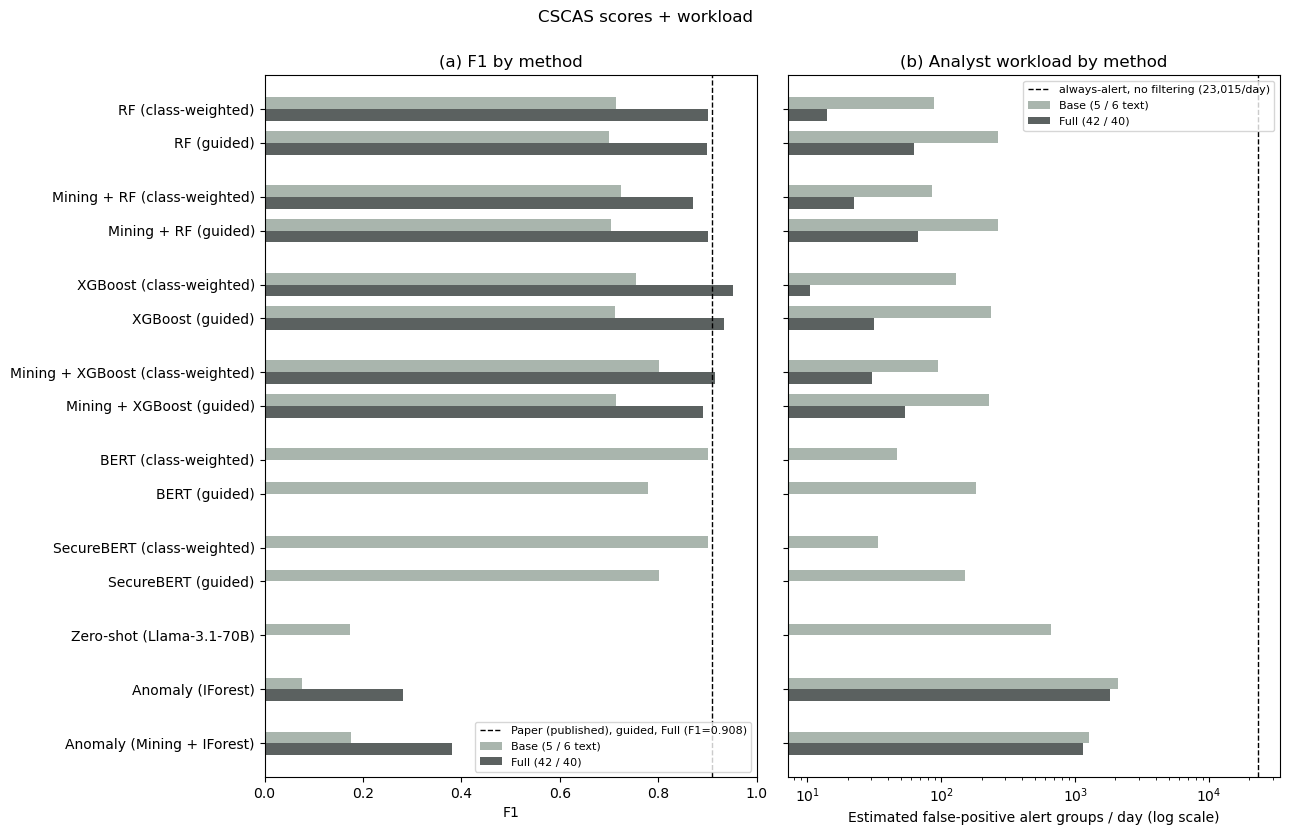

In [19]:
import numpy as np

# Shared row spec for both panels: method x training condition -> F1 and
# FP/day, Base vs Full schema. Broader than the compact summary table: both
# class-weighted and guided rows, plus Mining+RF and the plain
# Anomaly(IForest) row.
WORKLOAD_TRAIN_CONDITIONS = [c for c in TRAIN_CONDITIONS if c[0] != "random"]

# (label, kind, stem, schema_for_base_col, schema_for_full_col)
WORKLOAD_SPEC = [
    ("RF", "trainable_rf", None, "base", "full"),
    ("Mining + RF", "trainable", "cscas_mining", "base", "full"),
    ("XGBoost", "trainable", "cscas_xgboost", "base", "full"),
    ("Mining + XGBoost", "trainable", "cscas_mining_xgboost", "base", "full"),
    ("BERT", "trainable", "cscas_bert", "text", None),
    ("SecureBERT", "trainable", "cscas_securebert", "text", None),
]
# (label, stem, schema_for_base_col, schema_for_full_col) -- single-condition
# rows (zero-shot has no training step, anomaly detectors are benign-only).
WORKLOAD_FLAT_SPEC = [
    ("Zero-shot (Llama-3.1-70B)", "cscas_zeroshot_llama3.1-70b", "text", None),
    ("Anomaly (IForest)", "cscas_anomaly_iforest", "base", "full_noscas"),
    ("Anomaly (Mining + IForest)", "cscas_mining_anomaly_iforest", "base", "full_noscas"),
]


def _method_metrics(stem, schema, kind, cond):
    """(F1, FP/day) for one (stem, schema, training condition) cell, or
    (None, None) if that cell has no result file / no such schema column."""
    if schema is None or (stem is None and kind != "trainable_rf"):
        return None, None
    key = GRID_RF[(schema, "subsample")] if kind == "trainable_rf" else _compact_key(stem, schema)
    data = _result(key)
    if data is None:
        return None, None
    if kind == "flat":
        p, r, f1 = data["precision"], data["recall"], data["f1"]
    else:
        cond_data = data.get(cond)
        if cond_data is None:
            return None, None
        p, r, f1 = cond_data["precision"], cond_data["recall"], cond_data["f1"]
    _, _, _, _, fp_day = _counts(p, r, "Subsample")
    return f1, fp_day


# y positions with a small gap between method groups (mirrors the table's
# \\midrule/\\addlinespace grouping) instead of uniform spacing.
method_labels, base_f1, full_f1, base_fp, full_fp, method_pos = [], [], [], [], [], []
GROUP_GAP = 0.6
_y = 0.0
for label, kind, stem, schema_base, schema_full in WORKLOAD_SPEC:
    for cond_key, cond_label in WORKLOAD_TRAIN_CONDITIONS:
        method_labels.append(f"{label} ({cond_label})")
        f1b, fpb = _method_metrics(stem, schema_base, kind, cond_key)
        f1f, fpf = _method_metrics(stem, schema_full, kind, cond_key)
        base_f1.append(f1b)
        full_f1.append(f1f)
        base_fp.append(fpb)
        full_fp.append(fpf)
        method_pos.append(_y)
        _y += 1
    _y += GROUP_GAP
for label, stem, schema_base, schema_full in WORKLOAD_FLAT_SPEC:
    method_labels.append(label)
    f1b, fpb = _method_metrics(stem, schema_base, "flat", None)
    f1f, fpf = _method_metrics(stem, schema_full, "flat", None)
    base_f1.append(f1b)
    full_f1.append(f1f)
    base_fp.append(fpb)
    full_fp.append(fpf)
    method_pos.append(_y)
    _y += 1 + GROUP_GAP

ALWAYS_ALERT_FP_DAY = conf_rows[-1]["Est. FP/day"]  # from the confusion-count cell
PAPER_F1 = PAPER_TARGET["guided by CSCAS"]["f1"]  # 0.908, from the exhaustive-table cell

fig_height = max(5.5, 0.42 * len(method_labels) + 2)
fig, axes = plt.subplots(1, 2, figsize=(13, fig_height))

y = np.array(method_pos)
h = 0.35

# --- Panel (a): F1 by method, Base vs Full, paper's published F1 as a
# reference line (top-pick recommendation: a plain grouped F1 bar chart) ---
ax = axes[0]
base_f1_p = [np.nan if v is None else v for v in base_f1]
full_f1_p = [np.nan if v is None else v for v in full_f1]
ax.barh(y - h / 2, base_f1_p, height=h, label="Base (5 / 6 text)", color="#8A9B8FBB")
ax.barh(y + h / 2, full_f1_p, height=h, label="Full (42 / 40)", color="#5B6160")
ax.axvline(PAPER_F1, color="k", linestyle="--", linewidth=1,
           label=f"Paper (published), guided, Full (F1={PAPER_F1:.3f})")
ax.set_yticks(y)
ax.set_yticklabels(method_labels)
ax.set_ylim(y.max() + 1, y.min() - 1)
ax.set_xlim(0, 1.0)
ax.set_xlabel("F1")
ax.set_title("(a) F1 by method")
ax.legend(fontsize=8, loc="lower right")

# --- Panel (b): estimated FP alert-groups/day, Base vs Full ---
ax2 = axes[1]
base_fp_p = [np.nan if v is None else v for v in base_fp]
full_fp_p = [np.nan if v is None else v for v in full_fp]
ax2.barh(y - h / 2, base_fp_p, height=h, label="Base (5 / 6 text)", color="#8A9B8FBB")
ax2.barh(y + h / 2, full_fp_p, height=h, label="Full (42 / 40)", color="#5B6160")
ax2.axvline(ALWAYS_ALERT_FP_DAY, color="k", linestyle="--", linewidth=1,
            label=f"always-alert, no filtering ({ALWAYS_ALERT_FP_DAY:,.0f}/day)")
ax2.set_yticks(y)
ax2.set_yticklabels([])  # shares the y-axis labels from panel (a)
ax2.set_ylim(y.max() + 1, y.min() - 1)
ax2.set_xscale("log")
ax2.set_xlabel("Estimated false-positive alert groups / day (log scale)")
ax2.set_title("(b) Analyst workload by method")
ax2.legend(fontsize=8, loc="upper right")

fig.suptitle("CSCAS scores + workload", y=1.0)
fig.tight_layout()

fig_path_png = FIGURES_DIR / "cscas_workload.png"
fig_path_pdf = FIGURES_DIR / "cscas_workload.pdf"
fig.savefig(fig_path_png, dpi=150, bbox_inches="tight")
fig.savefig(fig_path_pdf, bbox_inches="tight")
print(f"Workload figure written to {fig_path_png} and {fig_path_pdf}")


## Full-grid scores + workload figure (appendix)

Same idea as the main-text figure above, but every row of
`table_rows` (built by the exhaustive LaTeX-table cell) instead of the
curated 15-row main-text subset -- 126 rows, one per (baseline, model,
feature schema, split, training condition) combination with a result file,
colored by section (Paper / Internal system / Internal + mining / LLM /
Anomaly) to match the table's own `\midrule` groupings. Repeated
Baseline/Model/Features/Split text is blanked within a block, same as the
LaTeX table.

* **(a)** F1 (mean $\pm$ sd where seeds exist), with the paper's published
  F1 (0.908, guided/Full) as a reference line. Anomaly rows are additionally
  annotated with AUC -- their F1 is at an arbitrary default
  contamination cut (0.05), so the bar alone understates those detectors
  (e.g. OneClassSVM Full-SCAS: F1 0.195-0.207 but AUC 0.956-0.962).
* **(b)** Estimated false-positive alert groups/day (log scale), same rows,
  same derivation (`_counts`) as the confusion-count table and the
  main-text figure. The `always-alert` ceiling is the same reference line.

This is meant as a companion to Table~\ref{tab:cscas-baseline-summary} in
the appendix, not a replacement for the main-text figure -- 126 rows only
really work as a full-page figure.

Writes `results/figures/cscas_full_grid_workload.png` and `.pdf`.


Full-grid figure: 126 rows, y-extent 136.6
Full-grid figure written to /Users/annavisman/stack/TUDelft/thesis/msc-thesis/src/thesis/baselines/results/figures/cscas_full_grid_workload.png and /Users/annavisman/stack/TUDelft/thesis/msc-thesis/src/thesis/baselines/results/figures/cscas_full_grid_workload.pdf


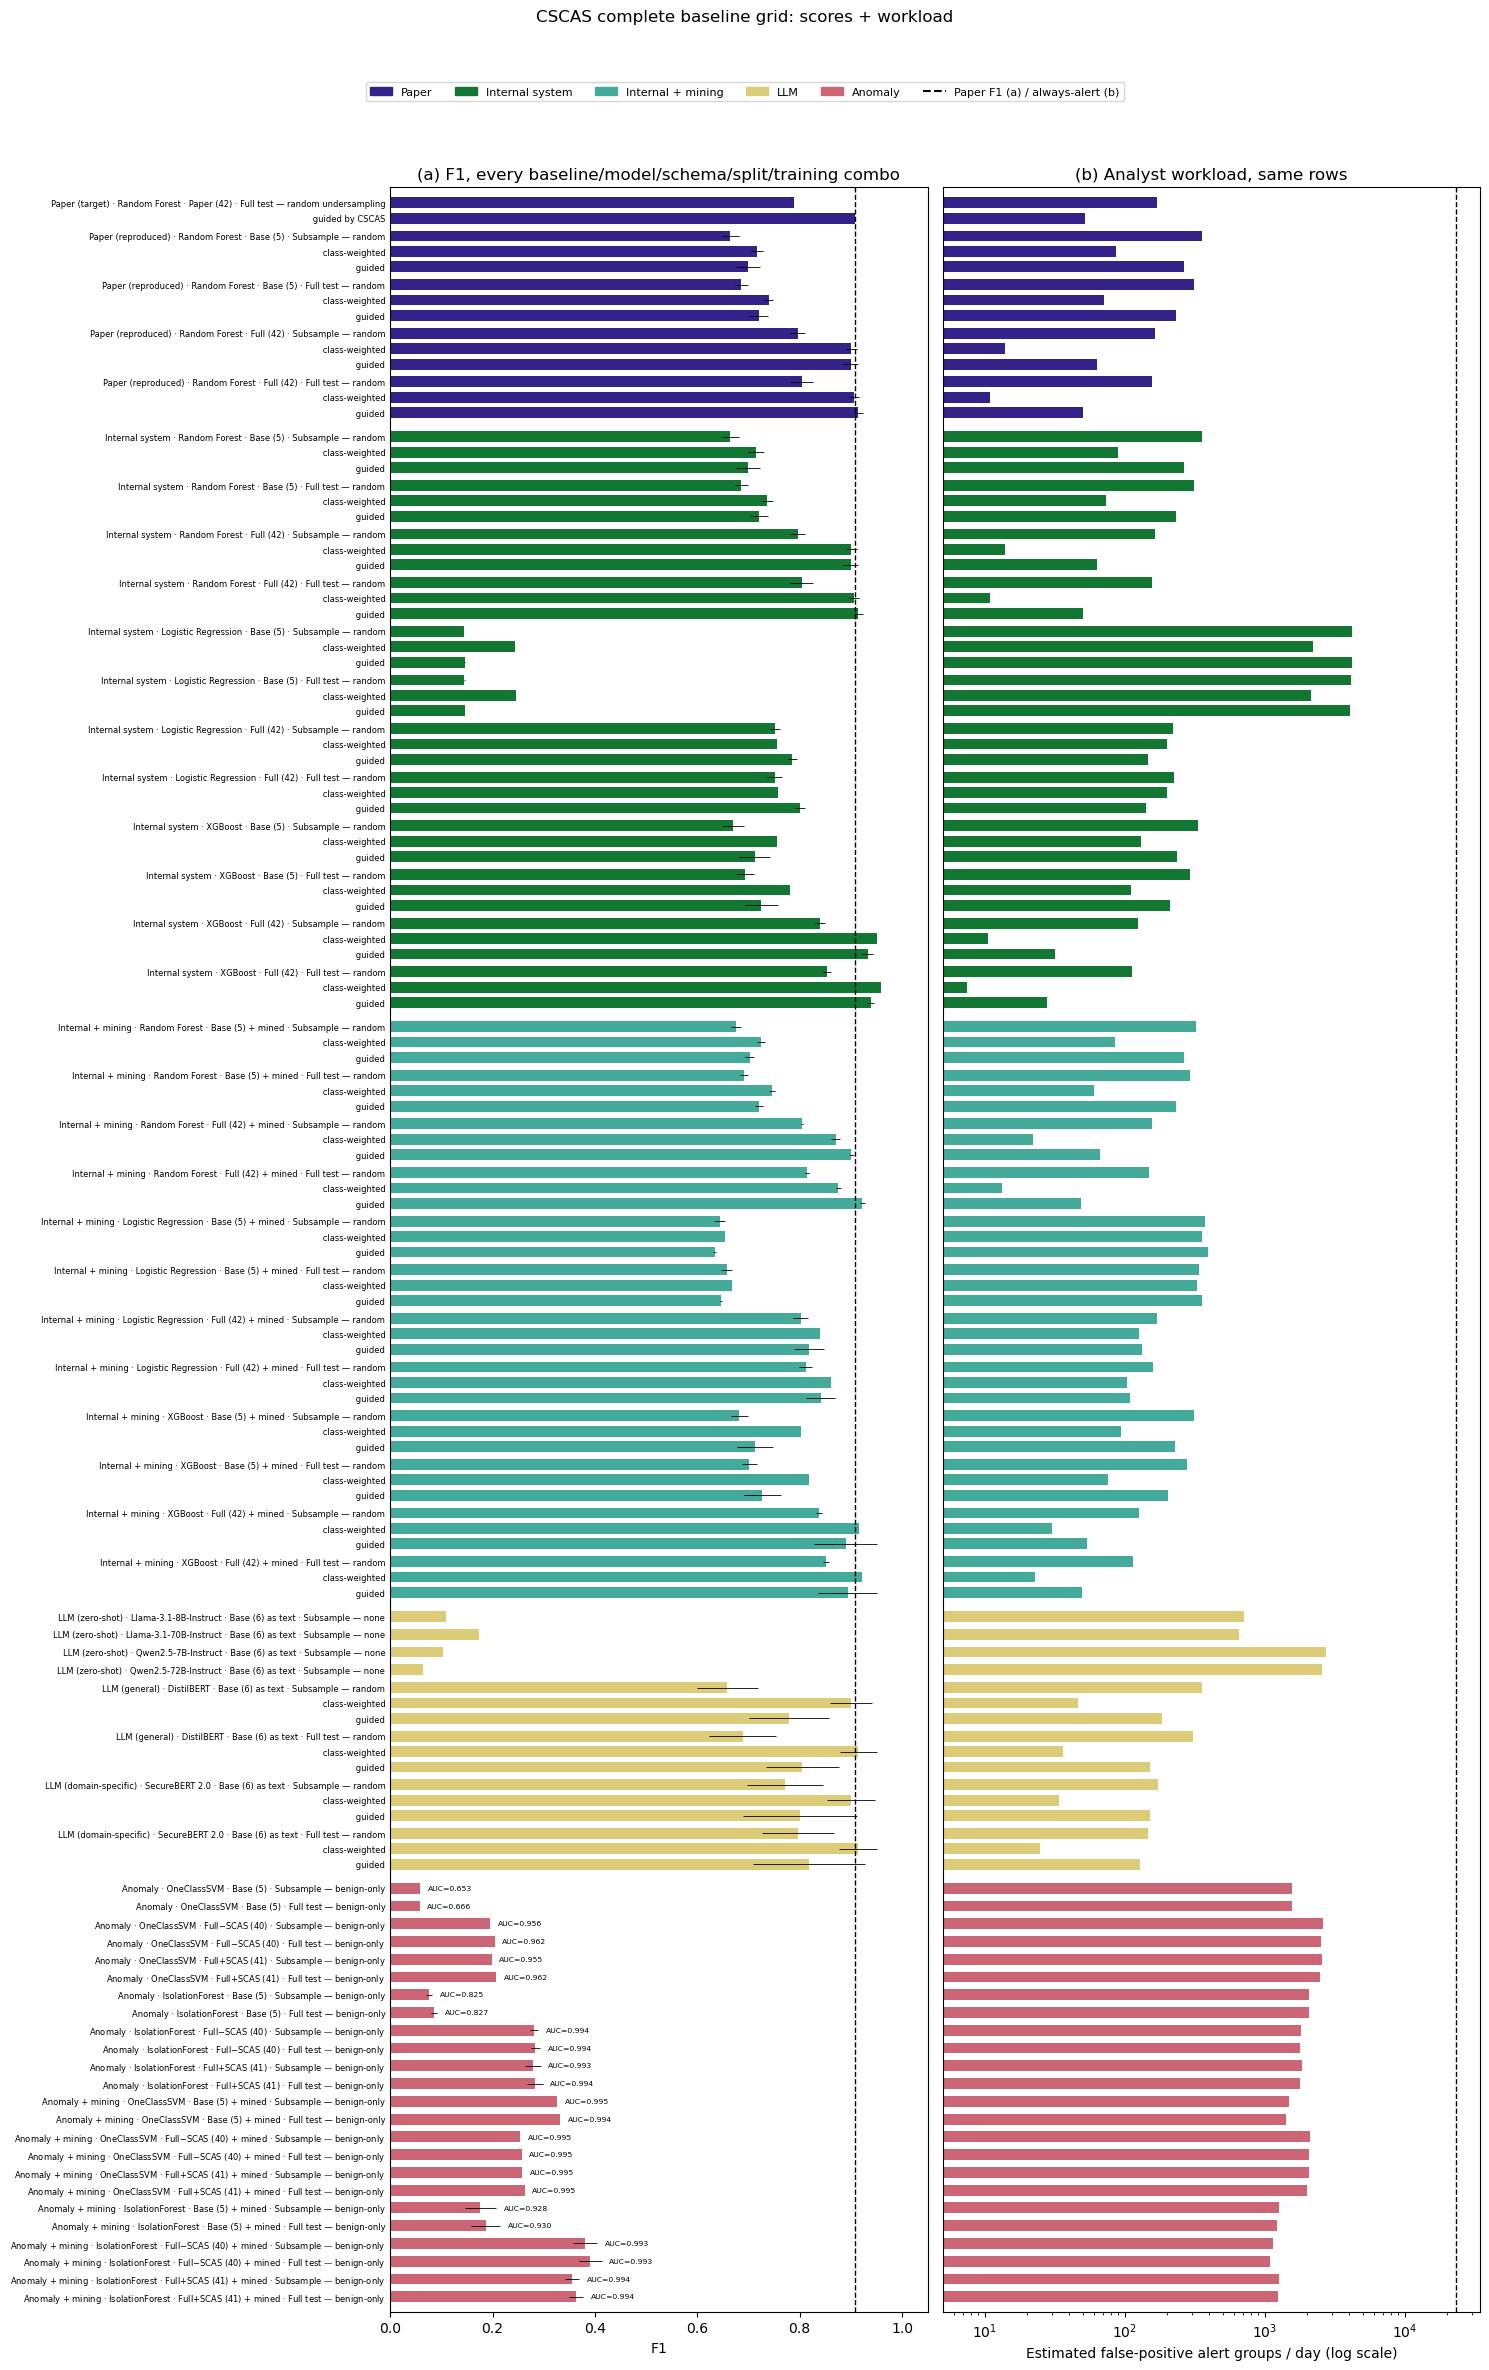

In [13]:
# --- Full-grid figure: every row of table_rows, not just the main-text subset ---
SECTION_LABEL = {
    "paper": "Paper", "internal": "Internal system", "mining": "Internal + mining",
    "llm": "LLM", "anom": "Anomaly",
}
SECTION_COLOR = {
    "paper": "#332288", "internal": "#117733", "mining": "#44AA99",
    "llm": "#DDCC77", "anom": "#CC6677",
}

full_labels, full_f1, full_f1_sd, full_fp, full_colors, full_pos, full_auc = [], [], [], [], [], [], []
BLOCK_GAP = 0.15
SECTION_GAP = 0.55
_y = 0.0
prev_gid = prev_section = None
for row in table_rows:
    if prev_gid is not None and row["gid"] != prev_gid:
        _y += SECTION_GAP if row["section"] != prev_section else BLOCK_GAP
    first = row["gid"] != prev_gid
    prev_gid, prev_section = row["gid"], row["section"]

    if first:
        label = f"{row['Baseline']} · {row['Model']} · {row['Features']} · {row['Split']} — {row['Training']}"
    else:
        label = f"      {row['Training']}"
    full_labels.append(label)
    full_f1.append(row["F1"])
    full_f1_sd.append(row["F1_sd"] or 0.0)
    full_colors.append(SECTION_COLOR[row["section"]])
    full_auc.append(row["AUC"])

    if row["Precision"] is not None and row["Recall"] is not None:
        _, _, _, _, fp_day = _counts(row["Precision"], row["Recall"], row["Split"])
    else:
        fp_day = None
    full_fp.append(fp_day)
    full_pos.append(_y)
    _y += 1

print(f"Full-grid figure: {len(full_labels)} rows, y-extent {_y:.1f}")

y = np.array(full_pos)
f1_p = [np.nan if v is None else v for v in full_f1]
f1_sd_p = [0.0 if v is None else v for v in full_f1_sd]
fp_p = [np.nan if v is None else v for v in full_fp]

fig_height = max(8, 0.155 * len(full_labels) + 3)
fig, axes = plt.subplots(1, 2, figsize=(15, fig_height))

ax = axes[0]
ax.barh(y, f1_p, height=0.7, color=full_colors, xerr=f1_sd_p,
        error_kw=dict(linewidth=0.6, ecolor="black"))
ax.axvline(PAPER_F1, color="k", linestyle="--", linewidth=1)
# Anomaly rows are shown at F1 (default contamination cut), but AUC is the
# threshold-free headline metric for that family -- annotate it so the
# (deliberately low) F1 bars aren't read as the whole story.
for yi, f1i, sdi, auci in zip(y, f1_p, f1_sd_p, full_auc):
    if auci is not None:
        ax.text(f1i + sdi + 0.015, yi, f"AUC={auci:.3f}", va="center", fontsize=5.5, color="black")
ax.set_yticks(y)
ax.set_yticklabels(full_labels, fontsize=6)
ax.set_ylim(y.max() + 1, y.min() - 1)
ax.set_xlim(0, 1.05)
ax.set_xlabel("F1")
ax.set_title("(a) F1, every baseline/model/schema/split/training combo")
ax.tick_params(axis="y", length=0)

ax2 = axes[1]
ax2.barh(y, fp_p, height=0.7, color=full_colors)
ax2.axvline(ALWAYS_ALERT_FP_DAY, color="k", linestyle="--", linewidth=1)
ax2.set_yticks(y)
ax2.set_yticklabels([])
ax2.set_ylim(y.max() + 1, y.min() - 1)
ax2.set_xscale("log")
ax2.set_xlabel("Estimated false-positive alert groups / day (log scale)")
ax2.set_title("(b) Analyst workload, same rows")
ax2.tick_params(axis="y", length=0)

legend_handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in SECTION_COLOR.values()]
legend_handles.append(plt.Line2D([0], [0], color="k", linestyle="--"))
legend_labels = list(SECTION_LABEL.values()) + ["Paper F1 (a) / always-alert (b)"]
fig.legend(legend_handles, legend_labels, loc="upper center", ncol=6,
           bbox_to_anchor=(0.5, 1.02), fontsize=8)

fig.suptitle("CSCAS complete baseline grid: scores + workload", y=1.05)
fig.tight_layout()

full_grid_fig_png = FIGURES_DIR / "cscas_full_grid_workload.png"
full_grid_fig_pdf = FIGURES_DIR / "cscas_full_grid_workload.pdf"
fig.savefig(full_grid_fig_png, dpi=150, bbox_inches="tight")
fig.savefig(full_grid_fig_pdf, bbox_inches="tight")
print(f"Full-grid figure written to {full_grid_fig_png} and {full_grid_fig_pdf}")
